# Tutorial: Direct Constitutive Calibration with Differentiable Forces 

**Goal**: fit Systematic Poking material parameters from *prescribed*
deformation states and their force responses -- with no equilibrium solve in
the fitting loop.

This notebook is the other part of the Systematic Poking torch tutorial
family:

- `static_solve_fitting.ipynb` fits the material from equilibrium reaction forces,
  where the displacement is the solution of a static solve;
- here the displacement is **data**: every sample is a homogeneous deformation
  field whose internal force `R = grad E(u; m)` is evaluated with
  `pypgo.fem.torch.StaticForceLayer`.  This is the "direct" or
  state-prescribed branch of constitutive calibration and is very cheap: one
  force evaluation per sample, no Newton iterations.

After the fit we run a predictive check: the directly calibrated material is
plugged into `StaticEquilibriumLayer` and its reaction-force curves under
unseen equilibrium load cases are compared with the Neo-Hookean target.

## Outline

1. Build the mesh and the shared deformation-energy operators;
2. `StaticEnergyLayer` vs `StaticForceLayer` -- what each backward provides;
3. Prescribe homogeneous deformation states (uniaxial + shear);
4. Generate "ground truth" force vectors with the target material;
5. Fit Systematic Poking parameters in log space (Adam, no Newton);
6. Predictive check: equilibrium reactions of the calibrated material;
7. Results and visualization.

## 0. Setup

The cell below adds the repository root to `sys.path` and silences the C++
backend's spdlog output. PyTorch is an optional dependency
(`pip install pypgo[torch]`); the torch layers live in `pypgo.fem.torch` and
are imported lazily.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pypgo").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch

import pypgo as pgo
import pypgo.fem as pf
import pypgo.solver as ps
from pypgo.fem.torch import (
    StaticEnergyLayer,
    StaticEquilibriumLayer,
    StaticForceLayer,
)

pgo.set_log_level("off")

## 1. Experiment configuration and mesh

The mesh is a unit cube split into `GRID_SIZE^3` hexahedra -- tiny, but enough
for meaningful force data.  All experimental constants live at the top.

In [2]:
TARGET_E, TARGET_NU = 2.0e5, 0.35   # target Neo-Hookean material
INIT_E, INIT_NU = 1.2e5, 0.25       # starting guess for the fit
FORCE_SCALE = TARGET_E              # forces/parameters normalized by E
STATIC_TOL = 1.0e-6                 # equilibrium residual threshold
SMOOTHNESS = 1.0e-3                 # second-difference regularization weight
KNOT_COUNT = 17                     # stretch/volume knots (must be odd)
GRID_SIZE = 2                       # grid: divisions along each axis
SHEARS = (-0.8, -0.4, 0.4, 0.8)     # training shear magnitudes


def make_grid(n: int = GRID_SIZE):
    ids = np.arange((n + 1) ** 3).reshape((n + 1, n + 1, n + 1))
    vertices = np.array(
        [[i / n, j / n, k / n]
         for i in range(n + 1) for j in range(n + 1) for k in range(n + 1)],
        dtype=np.float64,
    )
    elements = np.array(
        [[ids[i, j, k], ids[i + 1, j, k], ids[i + 1, j + 1, k],
          ids[i, j + 1, k], ids[i, j, k + 1], ids[i + 1, j, k + 1],
          ids[i + 1, j + 1, k + 1], ids[i, j + 1, k + 1]]
         for i in range(n) for j in range(n) for k in range(n)],
        dtype=np.int64,
    )
    return vertices, elements


vertices, elements = make_grid()
print(f"vertices = {len(vertices)}   elements = {len(elements)}   "
      f"displacement dofs = {vertices.size}")

vertices = 27   elements = 8   displacement dofs = 81


## 2. Energy layer vs force layer

`StaticEnergyLayer` evaluates `E(u; m)` and its backward exposes the exact
first derivatives: `dE/du` (the C++ force gradient), `dE/de` and `dE/dp`.
It is perfect for energy-based losses.

`StaticForceLayer` evaluates the full force vector `R(u; m) = grad E(u; m)`
directly.  Its backward uses the displacement Hessian (a sparse matvec) and
the material VJP -- the mixed second derivatives -- so the force output
*stays connected to the material parameters* in the autograd graph.  This is
the property that makes force matching work: with the energy layer alone,
`torch.autograd.grad(E, u)` returns the force but that value is detached from
the material branch (first-order only), so you could not differentiate a
force-based loss with respect to the material parameters.

In [3]:
def fixed_channel_block(elastic, num_elements):
    """Element-major fixed channels for the MaterialBinding."""
    if elastic.name == "neo_hookean":
        return np.tile([TARGET_E, TARGET_NU], (num_elements, 1))
    if elastic.name == "systematic_poking":
        # Knot locations live in the definition; no per-element fixed channels
        return np.empty((num_elements, 0), dtype=np.float64)
    raise ValueError(f"unsupported fixed channels for {elastic.name}")


def make_operator(elastic):
    """Build a shared CubicLinear operator for one material definition."""
    volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(*make_grid()),
        pgo.mesh.volume.ENuMaterial(E=TARGET_E, nu=TARGET_NU),
    )
    mesh = pf.SimulationMesh(volume)
    plastic = pf.VolumetricPlasticityDefinition(dofs=0)
    binding = pf.MaterialBinding(
        pf.ElasticMaterialBinding(
            elastic, mesh.num_elements,
            fixed_channel_block(elastic, mesh.num_elements)),
        pf.PlasticMaterialBinding(
            plastic, mesh.num_elements,
            np.empty((mesh.num_elements, 0), dtype=np.float64)),
    )
    return pf.DeformationEnergyOperator(
        mesh, binding,
        formulation=pf.CubicLinear(),
        options=pf.DeformationOptions(project_hessian_psd=False),
    )


knots = np.exp(np.linspace(np.log(0.5), np.log(2.0), KNOT_COUNT))
vol_knots = np.exp(np.linspace(-1.0, 1.0, KNOT_COUNT))
initial_params = np.concatenate([
    (INIT_E / (2 * (1 + INIT_NU))) * (1 + 1 / knots ** 2),
    [INIT_E * INIT_NU / ((1 + INIT_NU) * (1 - 2 * INIT_NU))],
])
systematic = pf.SystematicPokingDefinition(
    knots, KNOT_COUNT // 2, vol_knots, KNOT_COUNT // 2)

operator = make_operator(systematic)
target_operator = make_operator(pf.NeoHookeanDefinition())

force_layer = StaticForceLayer(energy_operator=operator)
target_force_layer = StaticForceLayer(energy_operator=target_operator)
energy_layer = StaticEnergyLayer(energy_operator=operator)

num_elements = operator.num_elements
plastic_empty = torch.empty((num_elements, 0), dtype=torch.float64)
target_empty = torch.empty((num_elements, 0), dtype=torch.float64)
print(f"systematic: {operator.num_dofs} dofs, "
      f"{operator.num_elastic_params} optimizable elastic channels/element")

systematic: 81 dofs, 18 optimizable elastic channels/element


## 3. Prescribed deformation states

Every sample is a **homogeneous** deformation field with all displacement
DOFs prescribed:

- confined uniaxial strain `u_y = (lambda - 1) y` at every non-rest stretch
  knot (so each spline interval is sampled);
- simple shear `u_x = gamma y` at four shear magnitudes.

No boundary-value problem is solved: the displacement is part of the data.

In [4]:
vertices, _ = make_grid()
stretches = np.array(
    [k for i, k in enumerate(knots) if i != KNOT_COUNT // 2])
shears = np.array(SHEARS)

states = []
for s in stretches:
    u = np.zeros_like(vertices)
    u[:, 1] = (s - 1.0) * vertices[:, 1]       # confined uniaxial strain
    states.append((f"uniaxial_{s:.3f}", u.ravel()))
for g in shears:
    u = np.zeros_like(vertices)
    u[:, 0] = g * vertices[:, 1]               # simple shear
    states.append((f"shear_{g:+.3f}", u.ravel()))

print(f"{len(states)} prescribed states")

# Probe: energy and force of the initial material at the first state.
probe_values = torch.as_tensor(
    np.broadcast_to(
        initial_params, (num_elements, initial_params.size)).copy(),
    dtype=torch.float64)
probe_u = torch.as_tensor(states[0][1], dtype=torch.float64)
probe_energy = energy_layer(probe_u, probe_values, plastic_empty)
probe_force = force_layer(probe_u, probe_values, plastic_empty)
print(f"E = {probe_energy.item():.6e}   ||R||/E = "
      f"{torch.norm(probe_force).item() / FORCE_SCALE:.6f}")

20 prescribed states
E = 2.698823e+04   ||R||/E = 0.391060


## 4. Generating the target force data

The target Neo-Hookean material has zero optimizable channels, so its layer
input is `(num_elements, 0)`.  We evaluate the full internal force vector of
every prescribed state and store it as `target_forces` -- the training
labels.

In [5]:
target_forces = torch.stack([
    target_force_layer(
        torch.tensor(u, dtype=torch.float64), target_empty, target_empty)
    for _, u in states
]).detach()

print("target force RMS / E = "
      f"{torch.sqrt(torch.mean((target_forces / FORCE_SCALE) ** 2)):.6f}")

target force RMS / E = 0.052176


## 5. Fitting the material parameters

The fitted parameters are $p$ (f'' spline values + lambda), optimized in
**log space**: $\theta = \log(p / E_0)$.  The loss is the mean squared
normalized force mismatch over all states plus a second-difference smoothness
term on the f'' knots.  The training loop is a standard PyTorch building
block: zero the gradients, compute the scalar loss, call `loss.backward()`,
and let `torch.optim.Adam` take a step.  Every function evaluation is just a
batch of `StaticForceLayer` forwards, so there is no equilibrium solve and no
implicit differentiation.

In [6]:
def forces(theta):
    """Force vector of every state for the current material parameters."""
    values = (FORCE_SCALE * torch.exp(theta)).expand(num_elements, -1)
    return torch.stack([
        force_layer(torch.tensor(u, dtype=torch.float64), values, plastic_empty)
        for _, u in states
    ])


def smoothness_penalty(theta, weight=SMOOTHNESS):
    """Second-difference penalty on f''(knot); lambda (last param) excluded."""
    if weight <= 0.0:
        return torch.tensor(0.0, dtype=theta.dtype)
    f_dd = theta[:-1]
    diff2 = f_dd[2:] - 2.0 * f_dd[1:-1] + f_dd[:-2]
    return weight * torch.mean(diff2 ** 2)


def loss_and_rmse(theta):
    """Total loss and force RMSE from the normalized force mismatch."""
    residual = (forces(theta) - target_forces) / FORCE_SCALE
    data_loss = torch.mean(residual ** 2)
    return data_loss + smoothness_penalty(theta), torch.sqrt(data_loss)


theta0 = torch.tensor(
    np.log(initial_params / FORCE_SCALE), dtype=torch.float64)

initial_loss, initial_rmse = loss_and_rmse(theta0)
initial_rmse = float(initial_rmse)
print(f"initial loss = {float(initial_loss):.6e}   "
      f"force RMSE / E = {initial_rmse:.6f}")

theta = theta0.detach().clone().requires_grad_(True)
optimizer = torch.optim.Adam([theta], lr=3.0e-2)

fit_history = []
for iteration in range(500):
    optimizer.zero_grad()
    loss, train_rmse = loss_and_rmse(theta)
    loss.backward()
    optimizer.step()

    fit_history.append({
        "iteration": iteration,
        "loss": float(loss.detach()),
        "train_rmse": float(train_rmse.detach()),
    })
    if iteration % 50 == 0 or iteration == 499:
        print(f"iter {iteration:3d}  loss={float(loss.detach()):.3e}  "
              f"train_rmse={float(train_rmse.detach()):.3e}")
    if float(train_rmse.detach()) < 1.0e-8:
        print("converged: force RMSE below tolerance")
        break

initial loss = 1.025720e-03   force RMSE / E = 0.032026
iter   0  loss=1.026e-03  train_rmse=3.203e-02
iter  50  loss=2.303e-05  train_rmse=4.772e-03
iter 100  loss=3.292e-07  train_rmse=4.248e-04
iter 150  loss=6.760e-08  train_rmse=1.270e-04
iter 200  loss=3.772e-08  train_rmse=6.759e-05
iter 250  loss=3.460e-08  train_rmse=7.749e-05
iter 300  loss=3.436e-08  train_rmse=8.355e-05
iter 350  loss=3.435e-08  train_rmse=8.509e-05
iter 400  loss=3.435e-08  train_rmse=8.537e-05
iter 450  loss=3.435e-08  train_rmse=8.540e-05
iter 499  loss=3.435e-08  train_rmse=8.541e-05


## 6. Results

The force residual drops by several orders of magnitude.  One caveat: force
data at a sampled stretch constrains the *integral* of f'' along the stretch
path, not the pointwise knot values, so the parameter table below is
informative rather than an identifiability statement -- the predictive check
in the next section is the real success metric.

In [7]:
fitted = FORCE_SCALE * torch.exp(theta.detach()).numpy()
mu, lam = (TARGET_E / (2 * (1 + TARGET_NU)),
           TARGET_E * TARGET_NU / ((1 + TARGET_NU) * (1 - 2 * TARGET_NU)))
reference = np.concatenate([mu * (1 + 1 / knots ** 2), [lam]])

fitted_rmse = torch.sqrt(torch.mean(
    ((forces(theta.detach()) - target_forces) / FORCE_SCALE) ** 2))
print(f"force RMSE / E: initial={float(initial_rmse):.6f}  "
      f"fitted={float(fitted_rmse):.6e}")
print(f"{'parameter':10s} {'fitted':>12s} {'reference':>12s}")
for i, name in enumerate([f"f_dd_{i}" for i in range(KNOT_COUNT)] + ["lambda"]):
    print(f"{name:10s} {fitted[i]:12.1f} {reference[i]:12.1f}")

force RMSE / E: initial=0.032026  fitted=8.540722e-05
parameter        fitted    reference
f_dd_0         358583.2     370370.4
f_dd_1         317947.9     323228.6
f_dd_2         281998.2     283587.2
f_dd_3         250397.0     250252.9
f_dd_4         222900.6     222222.2
f_dd_5         199279.7     198651.3
f_dd_6         179221.0     178830.6
f_dd_7         162348.9     162163.5
f_dd_8         148245.5     148148.1
f_dd_9         136477.8     136362.7
f_dd_10        126624.8     126452.4
f_dd_11        118294.2     118118.8
f_dd_12        111128.4     111111.1
f_dd_13        104815.8     105218.4
f_dd_14         99097.3     100263.2
f_dd_15         93790.7      96096.4
f_dd_16         88791.1      92592.6
lambda         170414.1     172839.5


## 7. Predictive check: equilibrium reactions

To verify the calibrated material, plug it into `StaticEquilibriumLayer` and
solve the same 36 reaction-force load cases used in the equilibrium-based
tutorials (free/confined uniaxial at every knot plus four shears).  The
fitted material was never trained on these equilibrium solves, so this
measures how well the direct calibration generalizes.

In [8]:
from dataclasses import dataclass


@dataclass
class LoadCase:
    label: str
    protocol: str
    coordinate: float
    fixed_dofs: np.ndarray
    fixed_values: np.ndarray
    free_dofs: np.ndarray
    reaction_selector: np.ndarray
    initial_displacement: np.ndarray
    target: float = 0.0


def constraints_from_mapping(mapping, num_dofs):
    fixed_dofs = np.array(sorted(mapping), dtype=np.int64)
    fixed_values = np.array([mapping[int(d)] for d in fixed_dofs], dtype=np.float64)
    free_dofs = np.setdiff1d(np.arange(num_dofs, dtype=np.int64), fixed_dofs)
    return fixed_dofs, fixed_values, free_dofs


def free_uniaxial_pins(vertices, bottom):
    positions = vertices[bottom]
    centroid = positions.mean(axis=0)
    d2 = ((positions[:, 0] - centroid[0]) ** 2 +
          (positions[:, 2] - centroid[2]) ** 2)
    anchor = int(bottom[np.argmin(d2)])
    same_z = bottom[np.isclose(vertices[bottom, 2], vertices[anchor, 2])]
    candidates = same_z[same_z != anchor]
    if candidates.size == 0:
        candidates = bottom[bottom != anchor]
    rotation_pin = int(candidates[np.argmax(
        np.abs(vertices[candidates, 0] - vertices[anchor, 0]))])
    return anchor, rotation_pin


def _boundary_vertices(vertices):
    bottom = np.flatnonzero(np.isclose(vertices[:, 1], 0.0))
    top = np.flatnonzero(np.isclose(vertices[:, 1], 1.0))
    return bottom, top


def free_uniaxial_cases(vertices, stretches):
    """Bottom fixed in y; top compressed along y; three rigid pins on the bottom."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for stretch in stretches:
        mapping = {}
        for v in bottom:
            mapping[3 * int(v) + 1] = 0.0
        for v in top:
            mapping[3 * int(v) + 1] = stretch - 1.0
        anchor, rotation_pin = free_uniaxial_pins(vertices, bottom)
        mapping[3 * anchor] = 0.0
        mapping[3 * anchor + 2] = 0.0
        mapping[3 * rotation_pin + 2] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top + 1] = 1.0
        initial = np.zeros(num_dofs)
        initial[1::3] = (stretch - 1.0) * vertices[:, 1]
        cases.append(LoadCase(
            label=f"free_uniaxial_{stretch:.3f}",
            protocol="free_uniaxial",
            coordinate=stretch,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def confined_uniaxial_cases(vertices, stretches):
    """Bottom fixed in y; top compressed along y; all x/z DOFs pinned."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for stretch in stretches:
        mapping = {}
        for v in bottom:
            mapping[3 * int(v) + 1] = 0.0
        for v in top:
            mapping[3 * int(v) + 1] = stretch - 1.0
        for v in range(len(vertices)):
            mapping[3 * v] = 0.0
            mapping[3 * v + 2] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top + 1] = 1.0
        initial = np.zeros(num_dofs)
        initial[1::3] = (stretch - 1.0) * vertices[:, 1]
        cases.append(LoadCase(
            label=f"confined_uniaxial_{stretch:.3f}",
            protocol="confined_uniaxial",
            coordinate=stretch,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def simple_shear_cases(vertices, shears):
    """Bottom fully fixed; top translated along x by the shear amount."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for shear in shears:
        mapping = {}
        for v in bottom:
            for c in range(3):
                mapping[3 * int(v) + c] = 0.0
        for v in top:
            mapping[3 * int(v)] = shear
            mapping[3 * int(v) + 1] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top] = 1.0
        initial = np.zeros(num_dofs)
        initial[0::3] = shear * vertices[:, 1]
        cases.append(LoadCase(
            label=f"simple_shear_{shear:+.3f}", protocol="simple_shear",
            coordinate=shear,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def make_cases(vertices, knots):
    """Build the three protocol families explicitly and concatenate them."""
    stretches = [k for i, k in enumerate(knots) if i != len(knots) // 2]
    return (
        free_uniaxial_cases(vertices, stretches)
        + confined_uniaxial_cases(vertices, stretches)
        + simple_shear_cases(vertices, SHEARS)
    )

In [9]:
cases = make_cases(operator.vertex_rest_positions, knots)
OPTIMIZER = ps.NewtonOptimizer(
    max_iterations=200,
    termination=ps.AbsoluteTermination(abs_tolerance=1.0e-10),
)


def equilibrium_layers(energy_operator):
    return [
        StaticEquilibriumLayer(
            energy_operator=energy_operator,
            fixed_dofs=case.fixed_dofs,
            fixed_values=case.fixed_values,
            reaction_selectors=case.reaction_selector,
            inner_optimizer=OPTIMIZER,
            sparse_backend=ps.EigenLDLT(),
            initial_displacement=case.initial_displacement,
            residual_tol=STATIC_TOL,
        )
        for case in cases
    ]


fitted_layers = equilibrium_layers(operator)
target_layers = equilibrium_layers(target_operator)

fitted_values = torch.as_tensor(
    np.broadcast_to(fitted, (num_elements, fitted.size)).copy(),
    dtype=torch.float64)
initial_values = torch.as_tensor(
    np.broadcast_to(initial_params, (num_elements, initial_params.size)).copy(),
    dtype=torch.float64)

fitted_reactions = torch.stack([
    layer(fitted_values, plastic_empty) for layer in fitted_layers]).detach()
initial_reactions = torch.stack([
    layer(initial_values, plastic_empty) for layer in fitted_layers]).detach()
target_reactions = torch.stack([
    layer(target_empty, target_empty) for layer in target_layers]).detach()

for case, value in zip(cases, target_reactions):
    case.target = float(value)

for name, reactions in (
        ("initial", initial_reactions), ("fitted", fitted_reactions)):
    rmse = torch.sqrt(torch.mean(
        ((reactions - target_reactions) / FORCE_SCALE) ** 2))
    print(f"{name} reaction RMSE / E = {float(rmse):.6f}")

initial reaction RMSE / E = 0.341117
fitted reaction RMSE / E = 0.001134


### Visualizing a solved configuration

Pick one equilibrium load case from the predictive check and render
the deformed surface of the directly calibrated material next to the
rest shape with `pgo.visualize`.  PyVista is an optional dependency:
the cell falls back to a message when it is not installed.

In [10]:
case = next(c for c in cases if c.protocol == "simple_shear")
layer = fitted_layers[cases.index(case)]
layer(fitted_values, plastic_empty)

try:
    pgo.visualize  # lazy import; requires pyvista
    HAS_VIZ = True
except Exception:
    HAS_VIZ = False

if HAS_VIZ:
    rest_volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(vertices, elements),
        pgo.mesh.volume.ENuMaterial(),
    )
    rest_surface = rest_volume.extract_surface_mesh()
    deformed = (
        operator.vertex_rest_positions
        + layer._last_displacement.reshape(-1, 3))
    deformed_volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(deformed, elements),
        pgo.mesh.volume.ENuMaterial(),
    )
    deformed_surface = deformed_volume.extract_surface_mesh()
    pgo.visualize.plot_surface(
        [rest_surface, deformed_surface],
        titles=["rest",
                f"fitted material, {case.protocol} "
                f"({case.coordinate:+.3f})"],
        colors=["lightgray", "lightsteelblue"],
        window_size=(800, 420),
        backend="jupyter",
    )
else:
    print("pyvista is not installed; skipping 3D visualization")


Widget(value='<iframe src="http://localhost:64197/index.html?ui=P_0x162367380_0&reconnect=auto" class="pyvista…

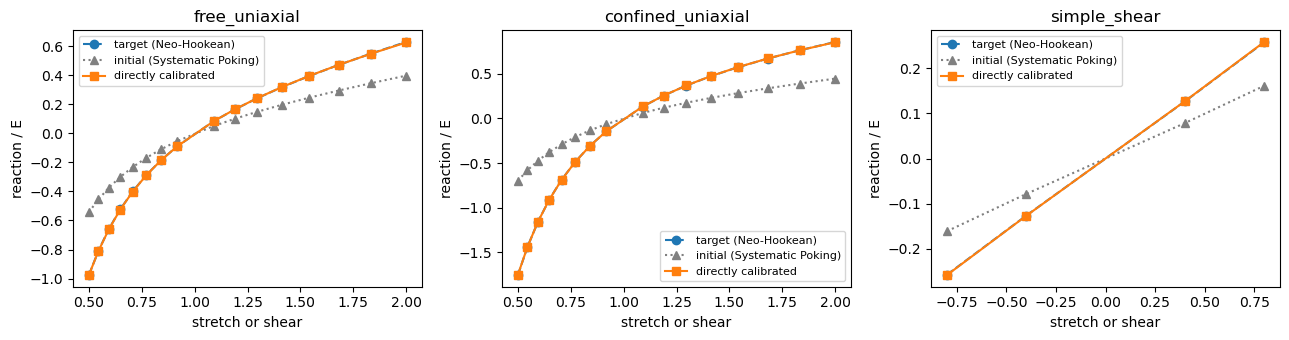

In [11]:
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for ax, protocol in zip(
            axes, ("free_uniaxial", "confined_uniaxial", "simple_shear")):
        sel = np.array([i for i, c in enumerate(cases) if c.protocol == protocol])
        order = np.argsort([cases[i].coordinate for i in sel])
        sel = sel[order]
        x_plot = [cases[i].coordinate for i in sel]
        ax.plot(x_plot, [cases[i].target / FORCE_SCALE for i in sel],
                "o--", label="target (Neo-Hookean)")
        ax.plot(x_plot, [initial_reactions[i] / FORCE_SCALE for i in sel],
                "^:", color="gray", label="initial (Systematic Poking)")
        ax.plot(x_plot, [fitted_reactions[i] / FORCE_SCALE for i in sel],
                "s-", label="directly calibrated")
        ax.set_title(protocol)
        ax.set_xlabel("stretch or shear")
        ax.set_ylabel("reaction / E")
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the plot")

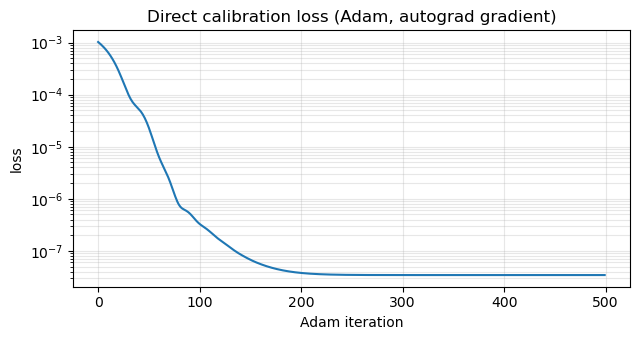

In [12]:
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.semilogy(
        [h["iteration"] for h in fit_history],
        [h["loss"] for h in fit_history],
        "-",
    )
    ax.set_xlabel("Adam iteration")
    ax.set_ylabel("loss")
    ax.set_title("Direct calibration loss (Adam, autograd gradient)")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the loss plot")